In [ ]:
#Import necesassry libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
sns.set_style('whitegrid')

In [ ]:
df = pd.read_csv('/content/Loan_default.csv', on_bad_lines='skip', low_memory=False)

In [ ]:
print(df.columns.tolist())

['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


In [ ]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [ ]:
df.shape

(255347, 18)

In [ ]:
df.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [ ]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


Object `default` not found.
Default rate: 11.6%


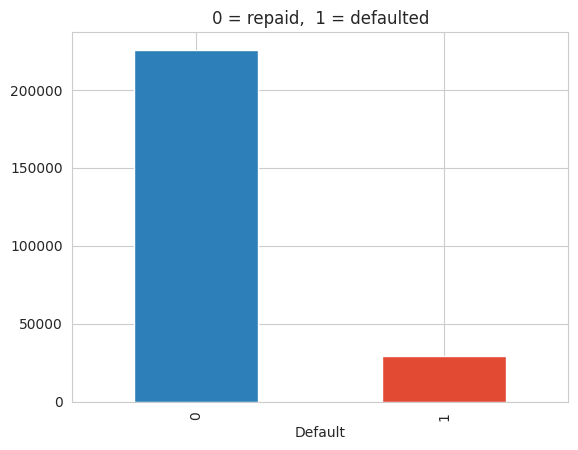

In [ ]:
Target balance — what % actually default?
rate = df['Default'].mean()
print(f'Default rate: {rate:.1%}')
df['Default'].value_counts().plot(kind='bar', color=['#2c7fb8','#e34a33'])
plt.title('0 = repaid,  1 = defaulted'); plt.show()

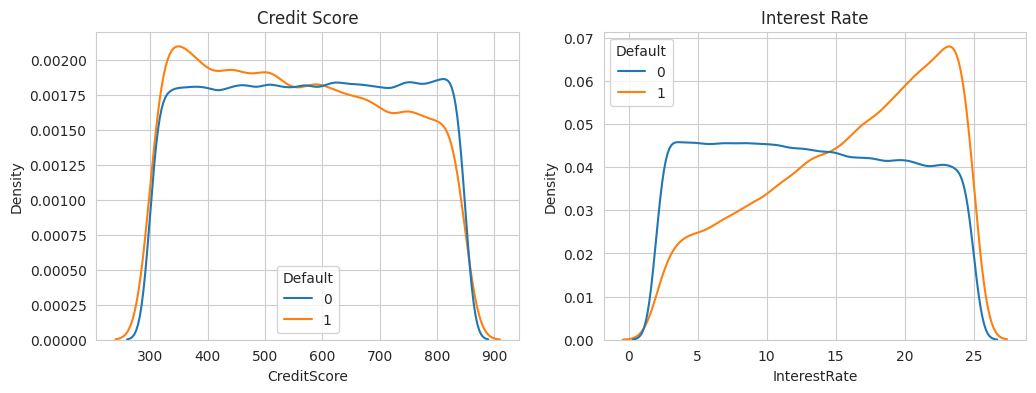

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

df['CreditScore'] = pd.to_numeric(df['CreditScore'], errors='coerce')

sns.kdeplot(data=df, x='CreditScore', hue='Default', common_norm=False, ax=ax[0])
ax[0].set_title('Credit Score')
sns.kdeplot(data=df, x='InterestRate', hue='Default', common_norm=False, ax=ax[1])
ax[1].set_title('Interest Rate')
plt.show()

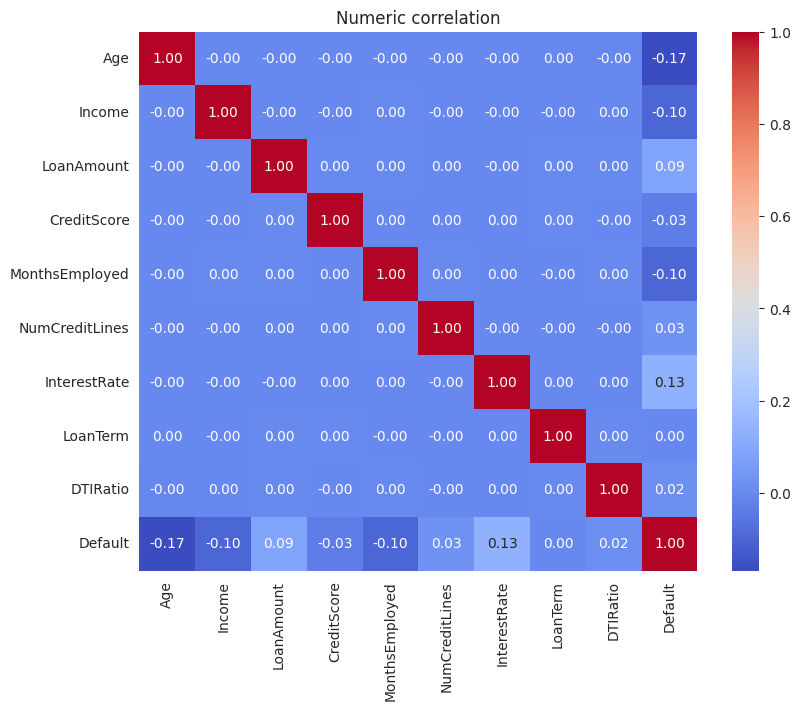

In [ ]:
num = ['Age','Income','LoanAmount','CreditScore','MonthsEmployed',
       'NumCreditLines','InterestRate','LoanTerm','DTIRatio']

# Convert all specified numeric columns to numeric type, coercing errors
for col in num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

plt.figure(figsize=(9,7))
sns.heatmap(df[num+['Default']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Numeric correlation')
plt.show()

In [ ]:
df_enc = pd.get_dummies(df.drop(columns=['LoanID']), drop_first=True)
df_enc = df_enc.dropna(subset=['Default'])
X = df_enc.drop(columns=['Default'])
y = df_enc['Default']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (204277, 24)  Test: (51070, 24)


In [ ]:
# Train a Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and binary classification
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
print(f"Logistic Regression F1-Score: {f1_log_reg:.4f}")

Logistic Regression Accuracy: 0.8842
Logistic Regression F1-Score: 0.0117


In [ ]:
# Feature Importance for Logistic Regression

feature_importance_log = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg_model.coef_[0]
})

# Sort by absolute importance
feature_importance_log['Absolute_Coefficient'] = abs(
    feature_importance_log['Coefficient']
)

feature_importance_log = feature_importance_log.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

feature_importance_log

,Feature,Coefficient,Absolute_Coefficient
0,Age,-0.041584,0.041584
6,InterestRate,0.027900,0.027900
4,MonthsEmployed,-0.009515,0.009515
7,LoanTerm,0.002709,0.002709
5,NumCreditLines,0.000977,0.000977
23,HasCoSigner_Yes,-0.000766,0.000766
18,HasDependents_Yes,-0.000726,0.000726
14,EmploymentType_Unemployed,0.000547,0.000547
3,CreditScore,-0.000486,0.000486
17,HasMortgage_Yes,-0.000469,0.000469


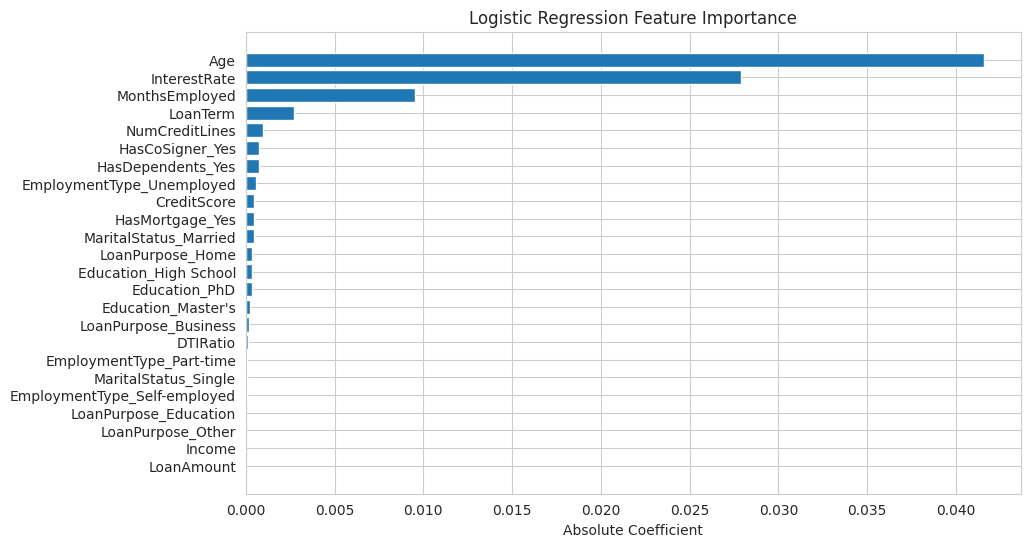

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_log['Feature'],
    feature_importance_log['Absolute_Coefficient']
)

plt.title("Logistic Regression Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest F1-Score: {f1_rf:.4f}")

Random Forest Accuracy: 0.8845
Random Forest F1-Score: 0.0134


In [ ]:
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

feature_importance_rf

,Feature,Importance
0,Age,0.226892
1,Income,0.188269
6,InterestRate,0.169212
2,LoanAmount,0.118471
4,MonthsEmployed,0.100475
3,CreditScore,0.049432
8,DTIRatio,0.034582
5,NumCreditLines,0.013601
7,LoanTerm,0.012341
23,HasCoSigner_Yes,0.011352


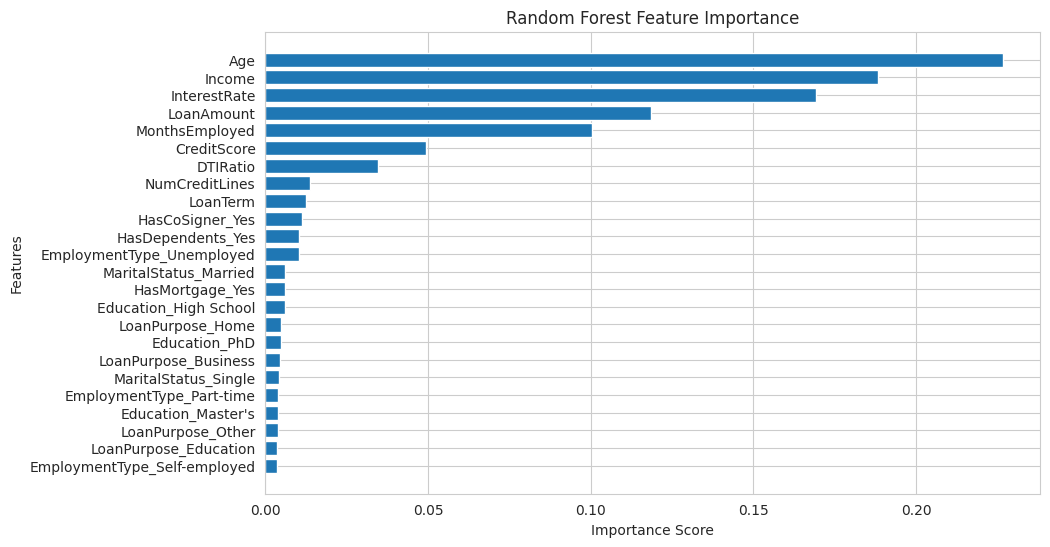

In [ ]:
# Random Forest Feature Importance

feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_rf['Feature'],
    feature_importance_rf['Importance']
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.gca().invert_yaxis()
plt.show()

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost F1-Score: {f1_xgb:.4f}")

XGBoost Accuracy: 0.8865
XGBoost F1-Score: 0.1208


In [ ]:
feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

feature_importance_xgb

,Feature,Importance
0,Age,0.169989
6,InterestRate,0.082955
1,Income,0.075762
18,HasDependents_Yes,0.062969
4,MonthsEmployed,0.056922
2,LoanAmount,0.056629
23,HasCoSigner_Yes,0.053547
14,EmploymentType_Unemployed,0.048719
13,EmploymentType_Self-employed,0.042326
15,MaritalStatus_Married,0.038597


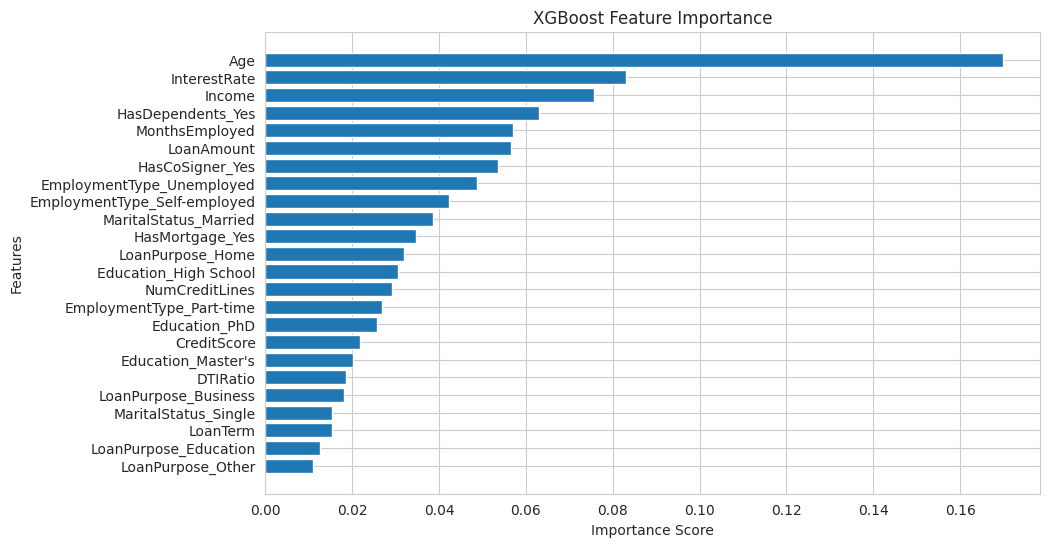

In [ ]:
# XGBoost Feature Importance

feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_xgb['Feature'],
    feature_importance_xgb['Importance']
)

plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.gca().invert_yaxis()
plt.show()

In [ ]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_log_reg,
        accuracy_rf,
        accuracy_xgb
    ],
    'F1 Score': [
        f1_log_reg,
        f1_rf,
        f1_xgb
    ]
})

comparison.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,F1 Score
2,XGBoost,0.886548,0.120789
1,Random Forest,0.884472,0.013378
0,Logistic Regression,0.884218,0.011700


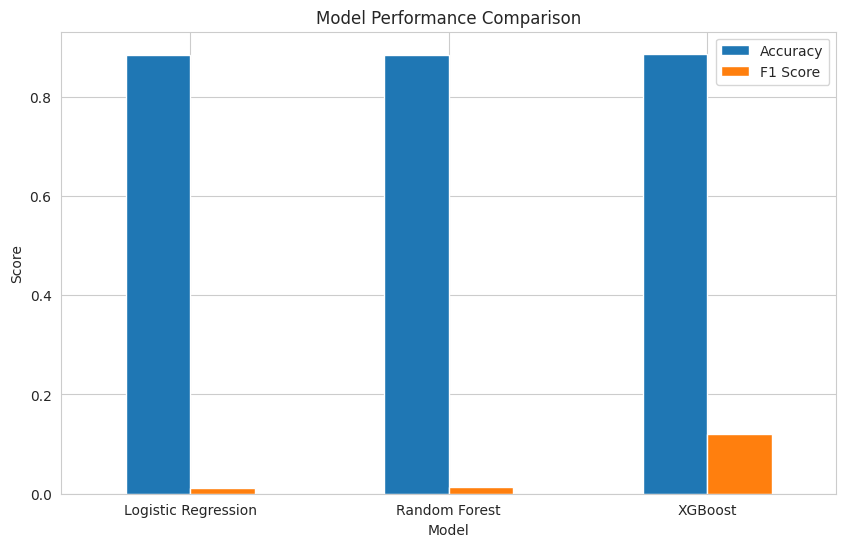

In [ ]:
comparison.set_index('Model')[['Accuracy','F1 Score']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [ ]:
best_model_name = comparison.sort_values(
    by='F1 Score',
    ascending=False
).iloc[0]['Model']

print("Best Model:", best_model_name)

Best Model: XGBoost


In [ ]:
import joblib

if best_model_name == "Logistic Regression":
    best_model = log_reg_model

elif best_model_name == "Random Forest":
    best_model = rf_model

else:
    best_model = xgb_model

joblib.dump(best_model, "loan_default_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [ ]:
app_py_content="""
import streamlit as st
import joblib
import pandas as pd

#page configuration
st.set_page_config(
    page_title="Loan Default Prediction",
    layout="wide",
    initial_sidebar_state="expanded"
)

#load model
model=joblib.load("loan_default_model.pkl")

#custom css
st.markdown('''
<style>
.main-header {font-size:36px; color:#4CAF50; text-align:center;}
.sub-header {font-size:24px; color:#2196F3; text-align:center;}
.stButton>button {width:100%; height:3em; font-size:18px;}
</style>
''',unsafe_allow_html=True)

#sidebar
with st.sidebar:
  st.image(
  "https://cdn-icons-png-flaticon.com/512/3135/3135715.png",
  width=150)
  st.title("Loan Default Prediction")
  st.markdown('''### Models Used
  - Logistic Regression
  - Random Forest
  - XGBoost
  ### Objective
  Predict whether a borrower is likely to default on a loan
  ### Features
  - Real-Time Prediction
  - Risk Probability
  - ML-powered Decision system
  ''')
st.divider()
st.info("Built with Streamlit, scikit-learn, and XGBoost.")

#Header
st.markdown("<h1 class='main-header'>Loan Default Prediction</h1>", unsafe_allow_html=True)
st.markdown("<h2 class='sub-header'>Machine Learning Powered Credit Risk Assessment Dashboard</h2>", unsafe_allow_html=True)
st.divider()

st.write("Please input the borrower's details below to get a loan default prediction.")

#Input section
col1, col2, col3 = st.columns(3)

# Numerical inputs
with col1:
 Age=st.number_input(
"Age",
min_value=18,
max_value=100,
value=30)
 Income=st.number_input(
"Income",
min_value=1000,
value=50000)
 LoanAmount=st.number_input(
"Loan Amount",
min_value=1000,
value=100000)

with col2:
  CreditScore = st.number_input(
  "Credit Score",
  min_value=300,
  max_value=850,
  value=650)
  InterestRate = st.number_input(
  "Interest Rate (%)",
  min_value=1.0,
  max_value=40.0,
  value=10.0)
  LoanTerm = st.number_input(
  "Loan Term (Months)",
 min_value=6,
 max_value=360,
 value=36 )

# Categorical inputs
with col3:
  MonthsEmployed = st.number_input(
  "Months Employed",
  min_value=0,
  value=5)

  NumCreditLines = st.number_input(
  "Number of Credit Lines",
  min_value=0,
  value=5)

  DTIRatio = st.number_input(
 "Debt-to-Income Ratio",
  min_value=0.0,
  max_value=1.0,
  value=0.30)

  Education = st.selectbox(
      "Education Level",
      ('Bachelor\'s', 'High School', 'Master\'s', 'PhD'))

  EmploymentType = st.selectbox(
      "Employment Type",
      ('Full-time', 'Unemployed', 'Self-employed', 'Part-time'))

  MaritalStatus = st.selectbox(
      "Marital Status",
      ('Divorced', 'Married', 'Single'))

  HasMortgage = st.radio(
      "Has Mortgage?",
      ('No', 'Yes'))

  HasDependents = st.radio(
      "Has Dependents?",
      ('No', 'Yes'))

  LoanPurpose = st.selectbox(
      "Loan Purpose",
      ('Auto', 'Business', 'Education', 'Home', 'Other'))

  HasCoSigner = st.radio(
      "Has Co-Signer?",
      ('No', 'Yes'))

# Prediction button
st.markdown('''<div style='text-align:center;'>''', unsafe_allow_html=True)
if st.button("Predict Loan Default"): # This should be outside of the column context
    # Prepare features for the model
    # Ensure the order and names match the training data X.columns
    input_data = pd.DataFrame([[Age, Income, LoanAmount, CreditScore, MonthsEmployed, NumCreditLines, InterestRate, LoanTerm, DTIRatio,
                                  1 if Education == 'High School' else 0,
                                  1 if Education == 'Master\'s' else 0,
                                  1 if Education == 'PhD' else 0,
                                  1 if EmploymentType == 'Part-time' else 0,
                                  1 if EmploymentType == 'Self-employed' else 0,
                                  1 if EmploymentType == 'Unemployed' else 0,
                                  1 if MaritalStatus == 'Married' else 0,
                                  1 if MaritalStatus == 'Single' else 0,
                                  1 if HasMortgage == 'Yes' else 0,
                                  1 if HasDependents == 'Yes' else 0,
                                  1 if LoanPurpose == 'Business' else 0,
                                  1 if LoanPurpose == 'Education' else 0,
                                  1 if LoanPurpose == 'Home' else 0,
                                  1 if LoanPurpose == 'Other' else 0,
                                  1 if HasCoSigner == 'Yes' else 0]],
                                columns=
                                [
                                    'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
                                    'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
                                    'Education_High School', 'Education_Master\'s', 'Education_PhD',
                                    'EmploymentType_Part-time', 'EmploymentType_Self-employed',
                                    'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single',
                                    'HasMortgage_Yes', 'HasDependents_Yes', 'LoanPurpose_Business',
                                    'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other',
                                    'HasCoSigner_Yes'
                                ])

    prediction = model.predict(input_data)[0]
    prediction_proba = model.predict_proba(input_data)[0][1] # Probability of default

    st.markdown("<hr>", unsafe_allow_html=True)
    st.markdown("<h3 style='text-align:center;'>Prediction Result</h3>", unsafe_allow_html=True)
    if prediction == 1:
        st.error(f"The model predicts that this borrower is LIKELY TO DEFAULT! (Probability: {prediction_proba:.2f})")
    else:
        st.success(f"The model predicts that this borrower is UNLIKELY TO DEFAULT. (Probability: {prediction_proba:.2f})")
st.markdown('''</div>''', unsafe_allow_html=True)
"""


In [ ]:
with open('app.py', 'w') as f:
    f.write(app_py_content)

print("Streamlit app code saved to app.py")

Streamlit app code saved to app.py


In [158]:
print(requirements_text)


## Application Requirements: Loan Default Prediction App (Streamlit Guidelines)

### 1. Functional Requirements

*   **Interactive Input Form (st.columns, st.number_input, st.selectbox, st.radio):** The application must present an organized and interactive form for users to input all necessary borrower details. This form should be structured using `st.columns` for a clean layout.
    *   **Numerical Inputs:** Use `st.number_input` for `Age`, `Income`, `Loan Amount`, `Credit Score`, `Months Employed`, `Number of Credit Lines`, `Interest Rate (%)`, `Loan Term (Months)`, and `Debt-to-Income Ratio`. Each input should have appropriate `min_value`, `max_value`, and `value` parameters for intuitive use.
    *   **Categorical Inputs:** Utilize `st.selectbox` for `Education Level`, `Employment Type`, `Marital Status`, and `Loan Purpose`. Use `st.radio` for binary choices like `Has Mortgage`, `Has Dependents`, and `Has Co-Signer`.
*   **Prediction Action (st.button):** A prominent `st.button` l

In [159]:
requirements_list = [
    'streamlit',
    'joblib',
    'pandas',
    'scikit-learn',
    'numpy',
    'matplotlib',
    'seaborn',
    'xgboost' # if using XGBoost
]

for req in requirements_list:
    print(req)

streamlit
joblib
pandas
scikit-learn
numpy
matplotlib
seaborn
xgboost


In [160]:
with open('requirements.txt', 'w') as f:
    for req in requirements_list:
        f.write(req + '\n')

print('requirements.txt created successfully!')

requirements.txt created successfully!


In [161]:
with open('runtime.txt', 'w') as f:
    f.write('python 3.10')

print('runtime.txt created successfully with Python 3.10 specified.')

runtime.txt created successfully with Python 3.10 specified.
